In [1]:
# Part C — Data Analysis and Visualization

# This notebook presents basic distributions and visualizations for the two selected datasets:
# 1. TCGA-OV Radiology metadata (TCIA)
# 2. TCGA-OV Proteogenomics metadata (TCIA)

# No machine learning methods are applied.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
radiology = pd.read_excel(
    "../data/raw/tcga-ov/TCIA_TCGA-OV_09-16-2015-nbia-digest.xlsx"
)
proteogenomics = pd.read_excel(
    "../data/raw/tcga_ov_proteogenomics/2020-02-26_Images_from_HGSOC_proteomics-nbia-digest.xlsx"
)

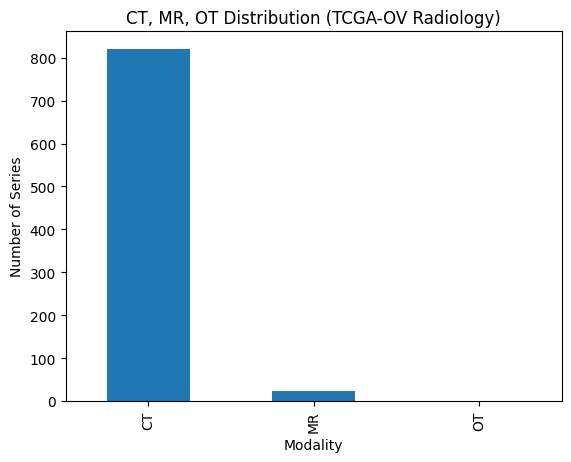

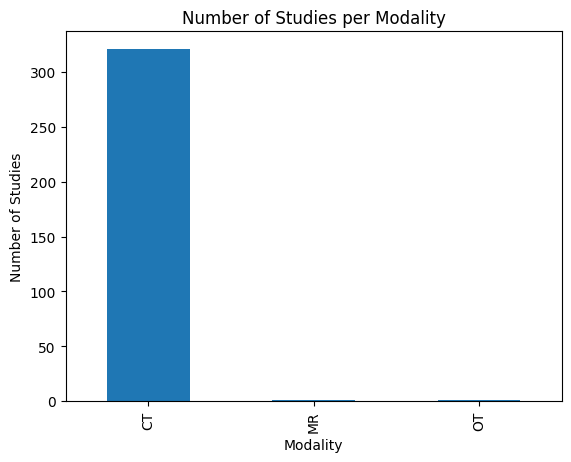

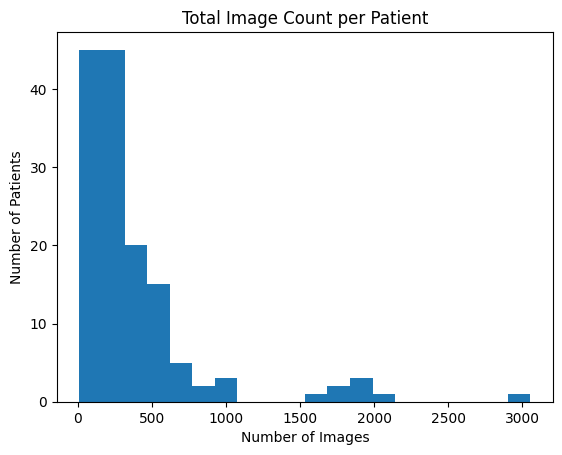

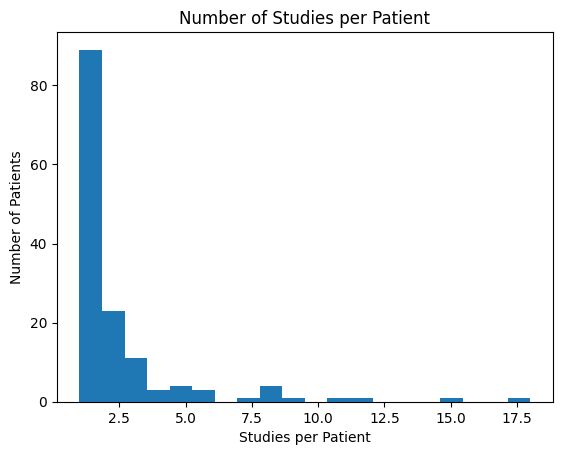

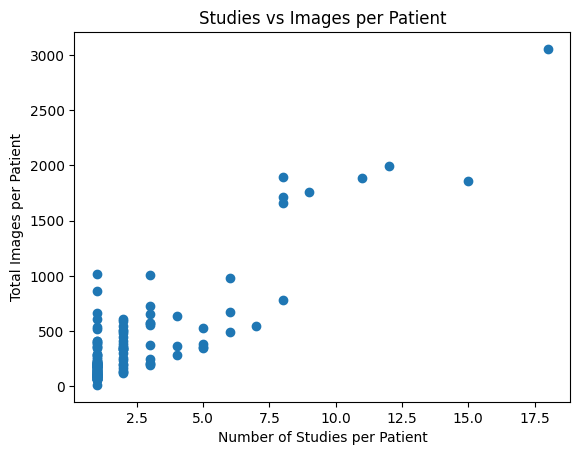

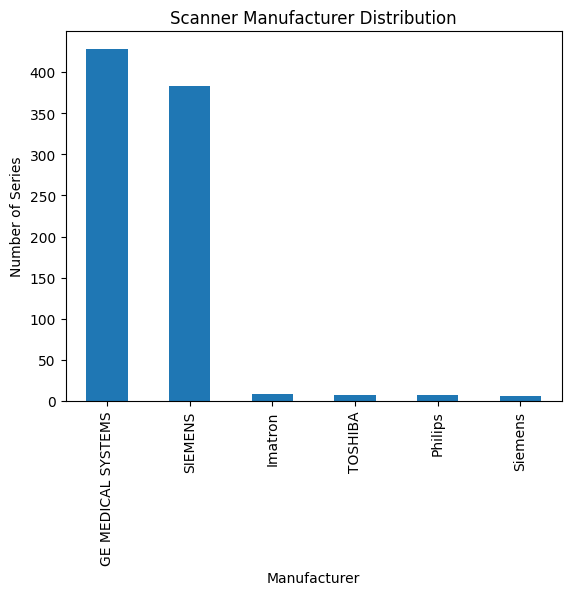

In [28]:
radiology['Modality'].value_counts().plot(kind='bar')
plt.title("CT, MR, OT Distribution (TCGA-OV Radiology)")
plt.xlabel("Modality")
plt.ylabel("Number of Series")
plt.show()
radiology.groupby('Modality')['Study Instance UID'].nunique().plot(kind='bar')
plt.title("Number of Studies per Modality")
plt.xlabel("Modality")
plt.ylabel("Number of Studies")
plt.show()
images_per_patient = radiology.groupby('Patient ID')['Image Count'].sum()
images_per_patient.plot(kind='hist', bins=20)
plt.title("Total Image Count per Patient")
plt.xlabel("Number of Images")
plt.ylabel("Number of Patients")
plt.show()
studies_per_patient = radiology.groupby('Patient ID')['Study Instance UID'].nunique()
studies_per_patient.plot(kind='hist', bins=20)
plt.title("Number of Studies per Patient")
plt.xlabel("Studies per Patient")
plt.ylabel("Number of Patients")
plt.show()
patient_summary = radiology.groupby('Patient ID').agg(
    studies=('Study Instance UID', 'nunique'),
    images=('Image Count', 'sum'))
plt.scatter(patient_summary['studies'], patient_summary['images'])
plt.xlabel("Number of Studies per Patient")
plt.ylabel("Total Images per Patient")
plt.title("Studies vs Images per Patient")
plt.show()
radiology['Manufacturer'].value_counts().plot(kind='bar')
plt.title("Scanner Manufacturer Distribution")
plt.xlabel("Manufacturer")
plt.ylabel("Number of Series")
plt.show()

In [29]:
# This is effectively a CT-only dataset
# Any imaging conclusions will be: CT-specific and not generalizable to MR-based ovarian imaging


In [30]:
# The total image count per patient shows strong skewness, with most patients contributing relatively few images and a small number contributing very large image volumes.
# This imbalance may bias image-based analyses toward patients with extensive imaging histories.


In [31]:
# Imaging follow-up is highly uneven
# This introduces coverage bias toward heavily imaged patients


In [32]:
# A positive relationship between number of studies and total images.
# Most patients have limited imaging, while a small number of patients undergo repeated imaging and contribute disproportionately large image volumes.
# The scanner manufacturer distribution indicates strong dominance of GE Medical Systems and Siemens scanners, with minimal representation from other vendors which introduces potential hardware-related bias.


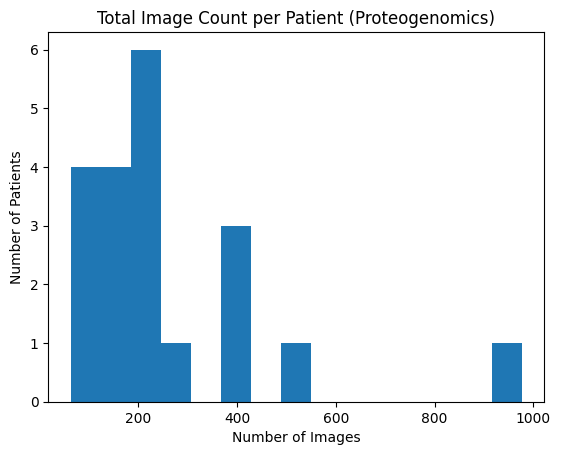

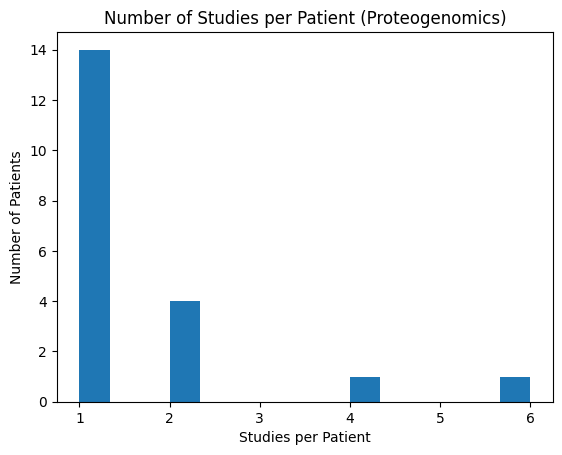

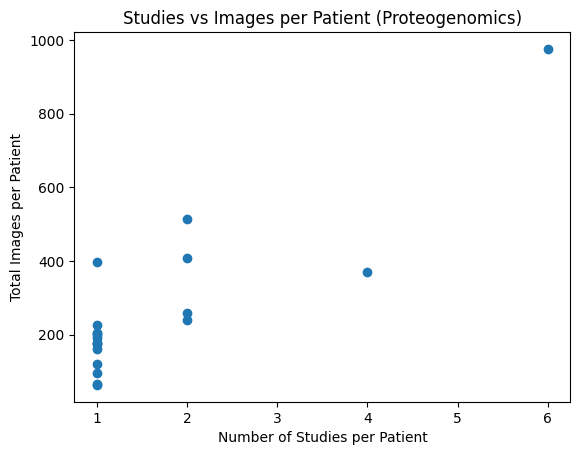

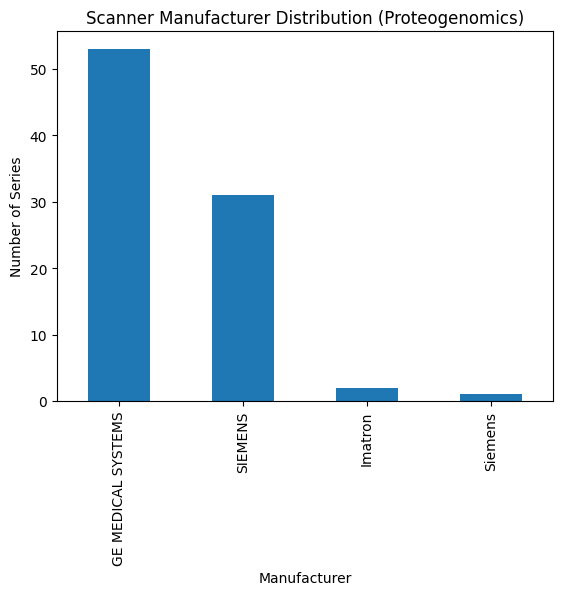

In [33]:
images_per_patient_pg = proteogenomics.groupby('Patient ID')['Image Count'].sum()
images_per_patient_pg.plot(kind='hist', bins=15)
plt.title("Total Image Count per Patient (Proteogenomics)")
plt.xlabel("Number of Images")
plt.ylabel("Number of Patients")
plt.show()
studies_per_patient_pg = proteogenomics.groupby('Patient ID')['Study Instance UID'].nunique()
studies_per_patient_pg.plot(kind='hist', bins=15)
plt.title("Number of Studies per Patient (Proteogenomics)")
plt.xlabel("Studies per Patient")
plt.ylabel("Number of Patients")
plt.show()
patient_summary_pg = proteogenomics.groupby('Patient ID').agg(
    studies=('Study Instance UID', 'nunique'),
    images=('Image Count', 'sum'))
plt.scatter(patient_summary_pg['studies'], patient_summary_pg['images'])
plt.xlabel("Number of Studies per Patient")
plt.ylabel("Total Images per Patient")
plt.title("Studies vs Images per Patient (Proteogenomics)")
plt.show()
proteogenomics['Manufacturer'].value_counts().plot(kind='bar')
plt.title("Scanner Manufacturer Distribution (Proteogenomics)")
plt.xlabel("Manufacturer")
plt.ylabel("Number of Series")
plt.show()

In [36]:
# Most patients in the proteogenomics cohort have only a single imaging study, with a small number of patients undergoing multiple studies.
# CT modality only dataset
# Also, looking at graphs you can infer some conclusions from above explainations.